In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

In [2]:
#load_diabetes()

In [3]:
df = load_diabetes()
df.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [4]:
diab = pd.DataFrame(df.data, columns = df.feature_names)
diab["target"] = df.target

In [5]:
diab.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [6]:
print(df.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [7]:
diab.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [8]:
diab["target"].describe().T

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In [9]:
pd.options.display.float_format = '{:.6f}'.format
diab.drop("target",axis=1).describe().T #data is standardised

,count,mean,std,min,25%,50%,75%,max
age,442.000000,-0.000000,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.000000,0.000000,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.000000,-0.000000,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.000000,-0.000000,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.000000,-0.000000,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.000000,0.000000,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.000000,-0.000000,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.000000,-0.000000,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.000000,0.000000,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.000000,0.000000,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


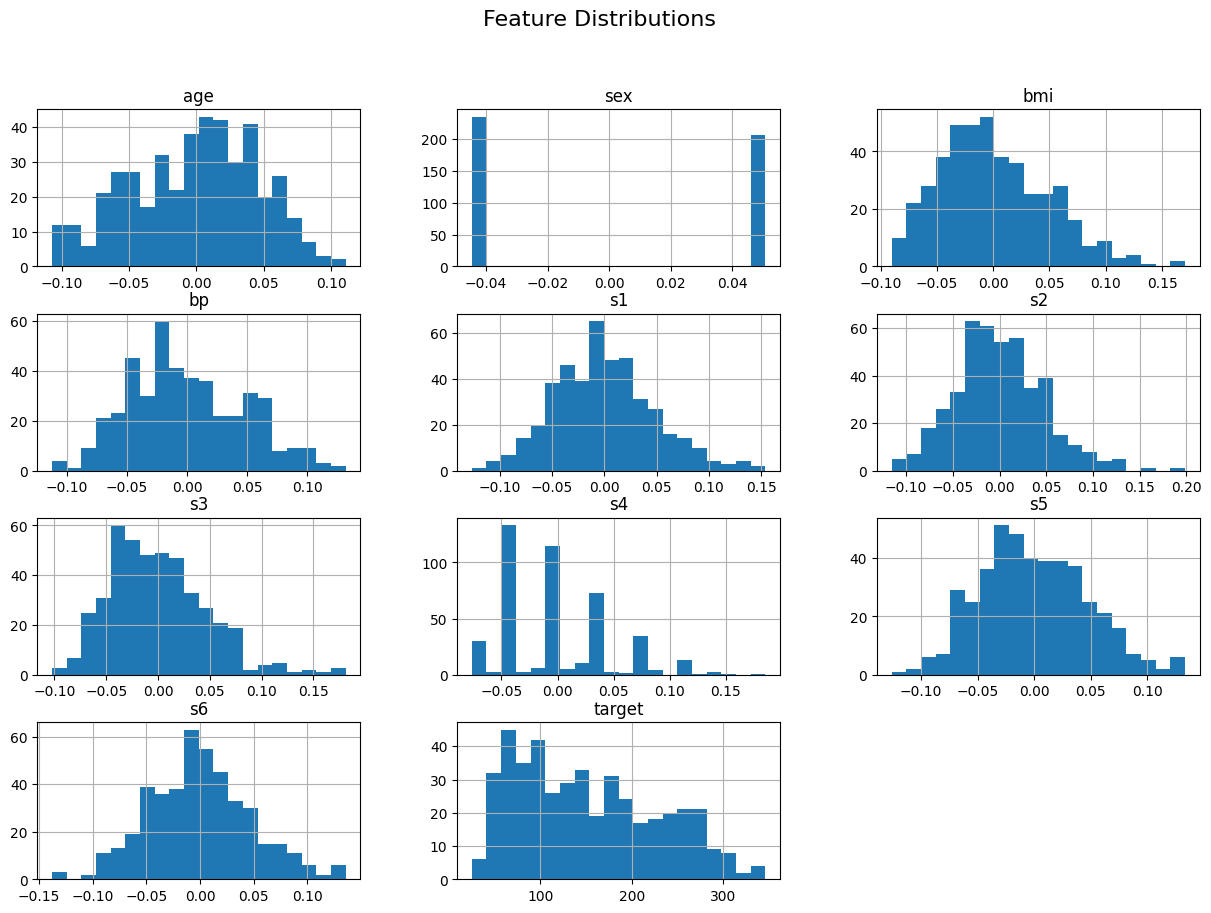

In [10]:
diab.hist(bins=20, figsize=(15, 10))
plt.suptitle("Feature Distributions", fontsize=16);

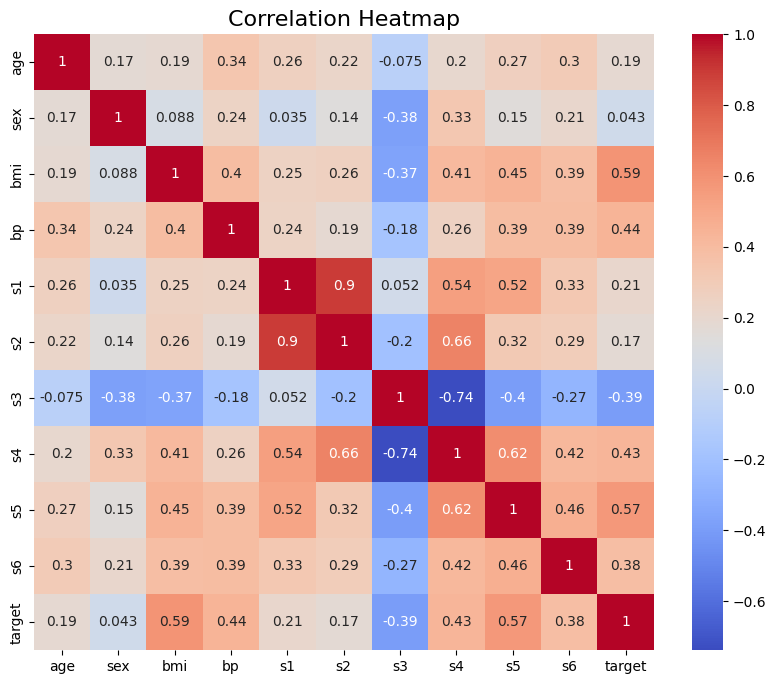

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(diab.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap", fontsize=16);

In [12]:
diab.corr()["target"].sort_values(ascending=False)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [14]:
X = diab.drop("target",axis=1)
y = diab["target"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [16]:
# Here Scaling is redundant
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)    #donot fit test data

#Linear Regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

#Error Metrics

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
r2  =r2_score(y_test,y_pred)

print(f"MSE : {mse}")
print(f"MAE : {mae}")
print(f"R2  : {r2}")

MSE : 2778.5804847818304
MAE : 42.434274612375475
R2  : 0.5651503625247859


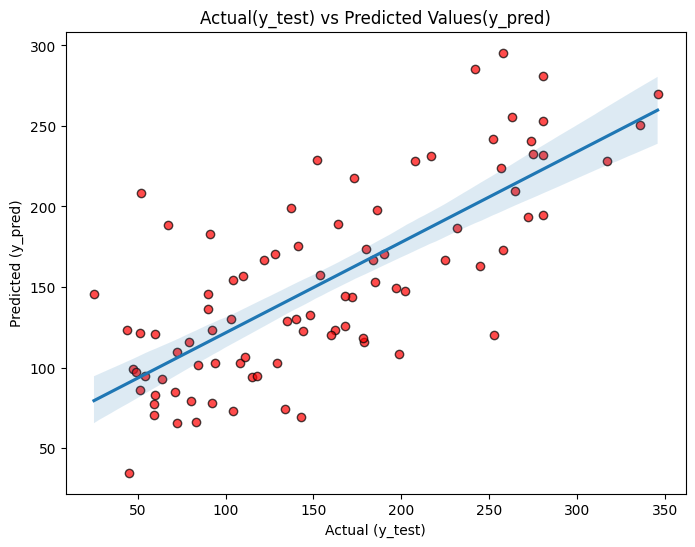

In [17]:
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.7, 
                                             'color':'red', 
                                             'edgecolor':'k'})
                             
plt.xlabel("Actual (y_test)")
plt.ylabel("Predicted (y_pred)")
plt.title("Actual(y_test) vs Predicted Values(y_pred)");



Polynomial Regression (degree=1):
MSE: 2778.5804847818304
MAE: 42.434274612375475
R2: 0.5651503625247859


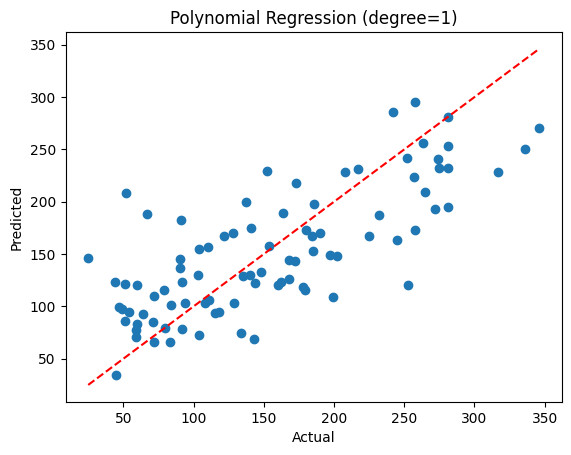


Polynomial Regression (degree=2):
MSE: 3341.5680030612734
MAE: 43.893258130484895
R2: 0.47704245290412617


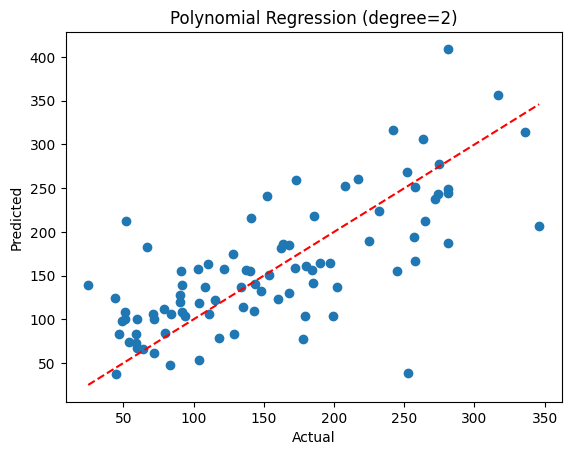


Polynomial Regression (degree=3):
MSE: 749310.6603965398
MAE: 254.56753435045744
R2: -116.26760150168292


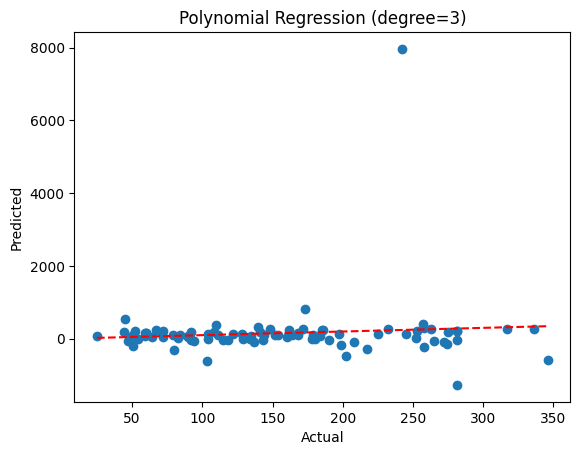


Polynomial Regression (degree=4):
MSE: 267062.73695747426
MAE: 267.8489646649732
R2: -40.795490533798464


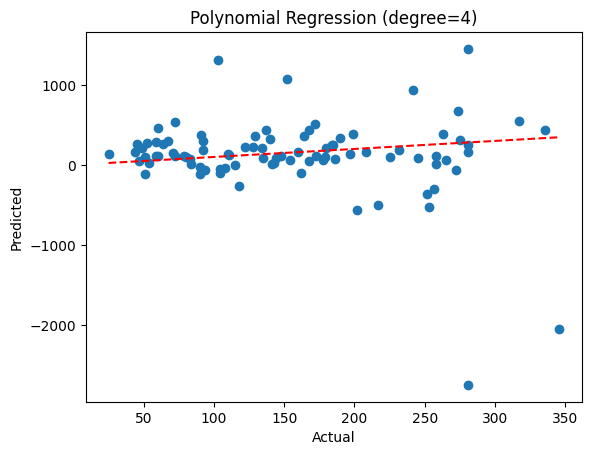

In [18]:
# Use pipe for cleaner code and iterate for degree of freedom
import warnings

# Ignore all runtime warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

degrees = [1, 2, 3, 4]

# Store error metric for each iteration/degree of polynomial
mse_list = []
mae_list = []
r2_list  = []

for degree in degrees:
    poly_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('regressor', LinearRegression())
    ])
    poly_pipe.fit(X_train, y_train)
    y_pred_poly = poly_pipe.predict(X_test)

    mse = mean_squared_error(y_test, y_pred_poly)
    mae = mean_absolute_error(y_test, y_pred_poly)
    r2  = r2_score(y_test, y_pred_poly)

    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)

    print(f"\nPolynomial Regression (degree={degree}):")
    print("MSE:", mse)
    print("MAE:", mae)
    print("R2:", r2)

    plt.scatter(y_test, y_pred_poly)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Polynomial Regression (degree={degree})")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.show()
  


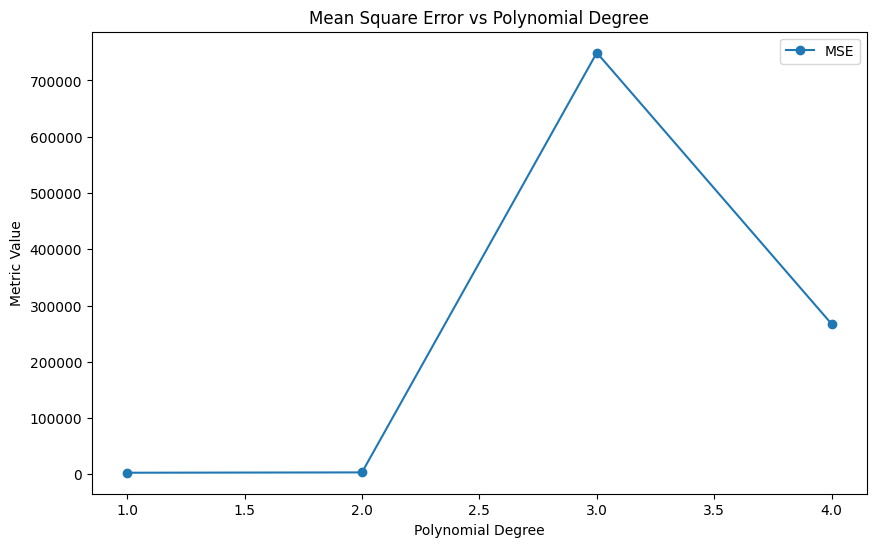

In [19]:
# Mean Square Error
plt.figure(figsize=(10,6))
plt.plot(degrees, mse_list, marker='o', label="MSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("Metric Value")
plt.title("Mean Square Error vs Polynomial Degree")
plt.legend();

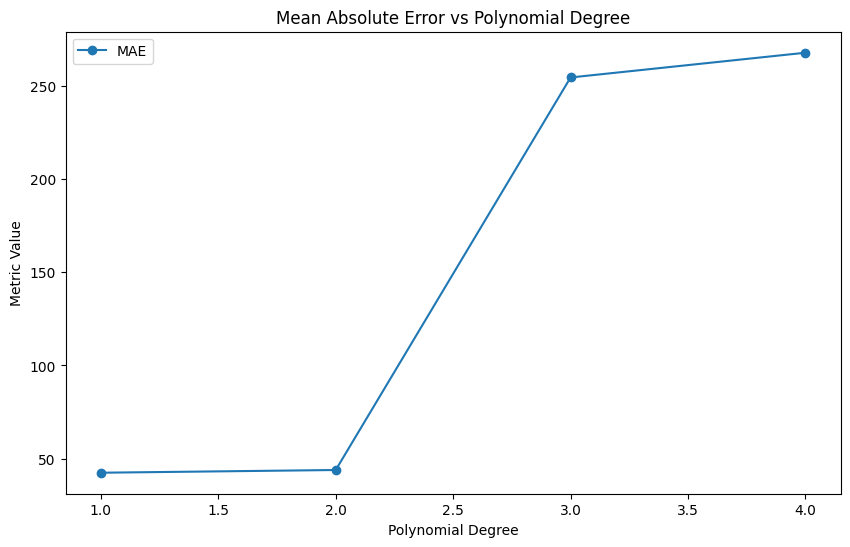

In [20]:
# Mean Absolute Error
plt.figure(figsize=(10,6))
plt.plot(degrees, mae_list, marker='o', label="MAE")
plt.xlabel("Polynomial Degree")
plt.ylabel("Metric Value")
plt.title("Mean Absolute Error vs Polynomial Degree")
plt.legend();

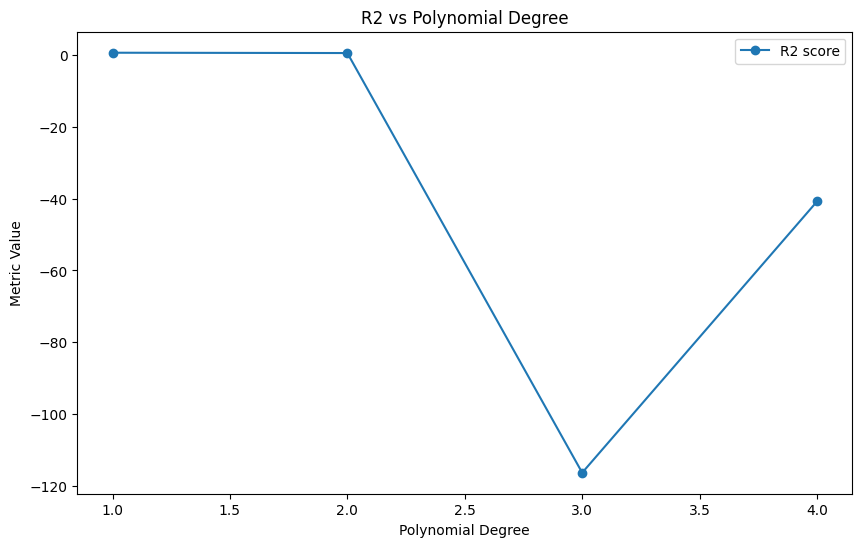

In [21]:
# R2 
plt.figure(figsize=(10,6))
plt.plot(degrees, r2_list, marker='o', label="R2 score")
plt.xlabel("Polynomial Degree")
plt.ylabel("Metric Value")
plt.title("R2 vs Polynomial Degree")
plt.legend();